In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
%matplotlib inline


sns.set(style="whitegrid")

In [7]:
df = pd.read_csv('Ecommerce Customers')

df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [9]:
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [11]:
df.columns

Index(['Email', 'Address', 'Avatar', 'Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership', 'Yearly Amount Spent'],
      dtype='object')

In [15]:
print("Shape:", df.shape)
print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing_count").T)

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (500, 8)

Missing values per column:


,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
missing_count,0,0,0,0,0,0,0,0



Duplicate rows: 0


In [24]:
drop_cols = ["Avatar", "Email","Address"]

drop_cols = [c for c in drop_cols if c in df.columns]

df = df.drop(columns=drop_cols)

In [25]:
df['Total_Time'] = df['Time on App'] + df['Time on Website']
df.head()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent,Total_Time
0,34.497268,12.655651,39.577668,4.082621,587.951054,52.233319
1,31.926272,11.109461,37.268959,2.664034,392.204933,48.378420
2,33.000915,11.330278,37.110597,4.104543,487.547505,48.440875
3,34.305557,13.717514,36.721283,3.120179,581.852344,50.438796
4,33.330673,12.795189,37.536653,4.446308,599.406092,50.331842


In [33]:
# df['Membership_Tier'] = pd.cut(df['Length of Membership'],
#                                 bins=[0, 1, 3, 5, 8],
#                                 labels=['New', 'Regular', 'Loyal', 'Veteran'])
# df.head()

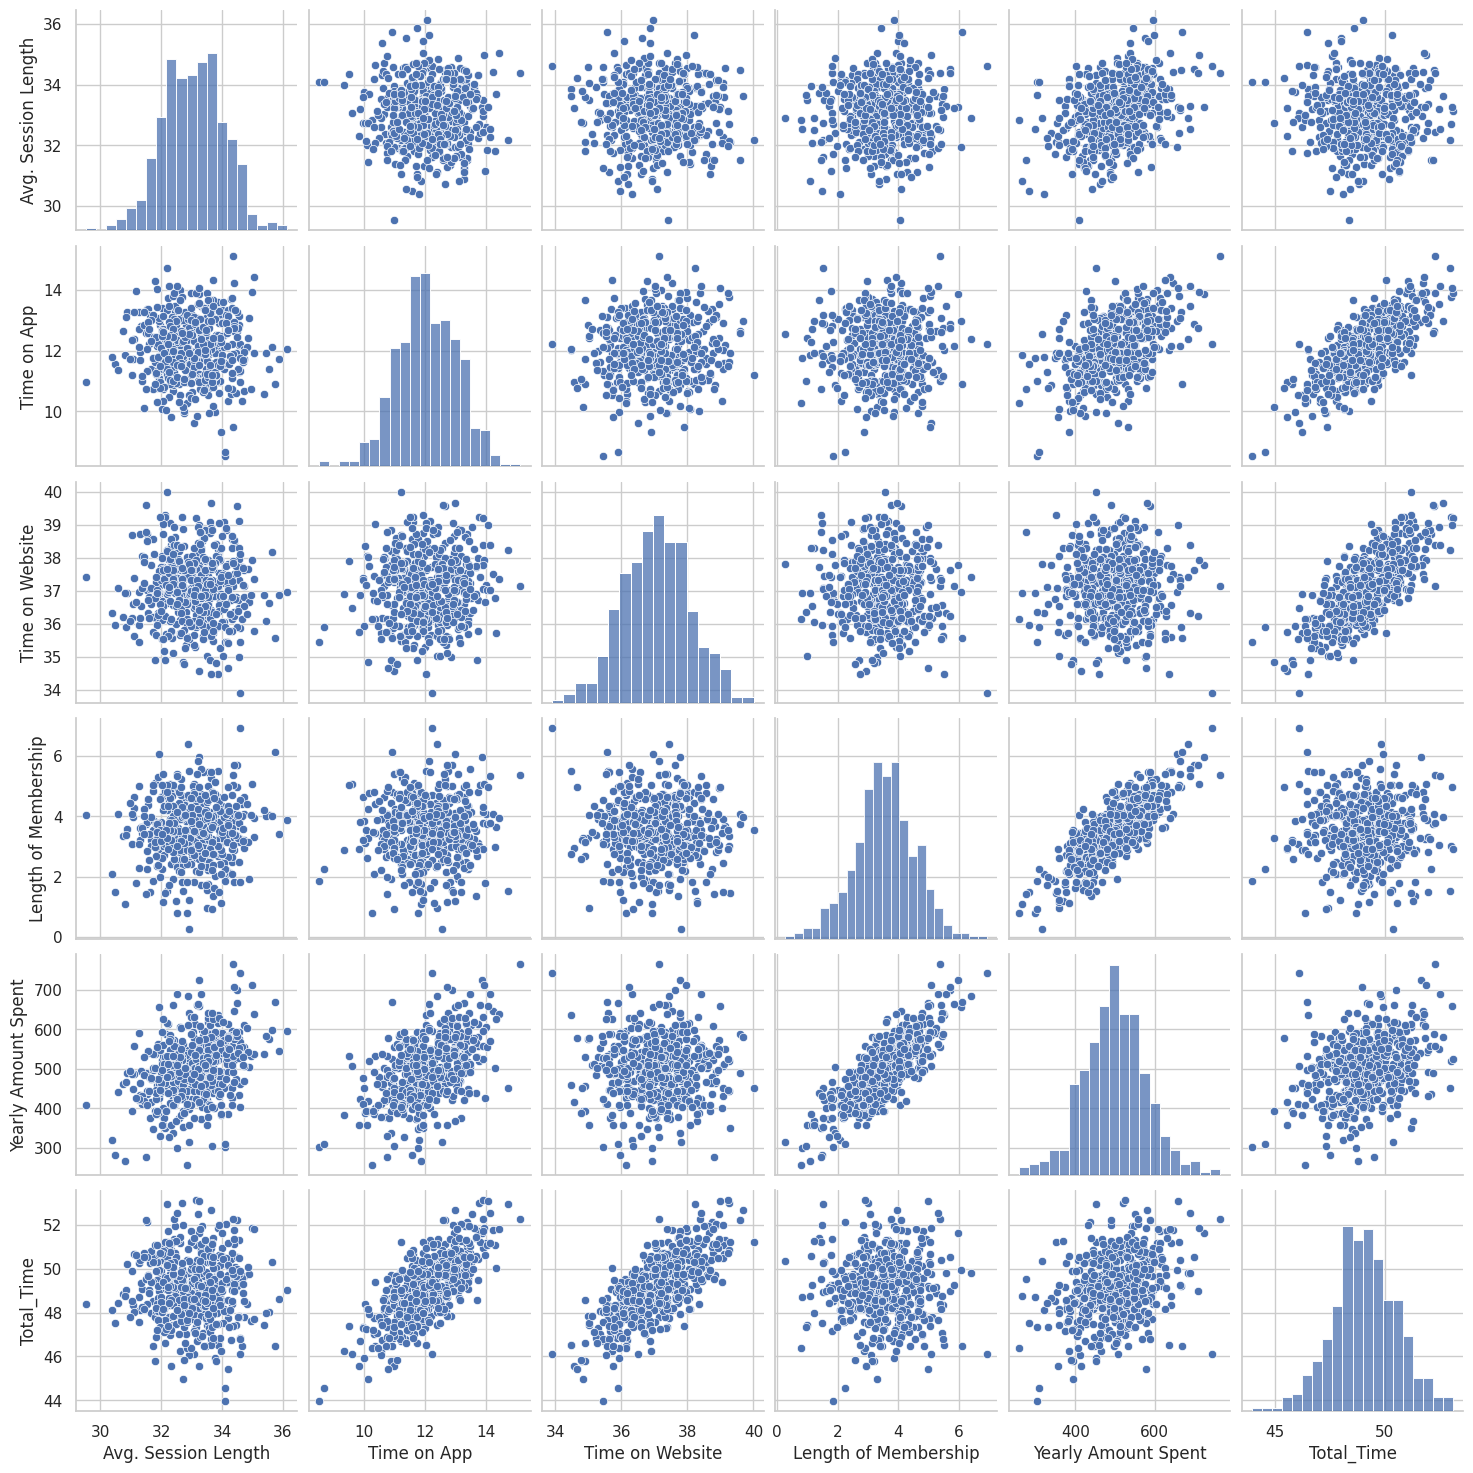

In [34]:
sns.pairplot(df)

/tmp/ipykernel_3575/429359120.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Yearly Amount Spent'])


<Axes: xlabel='Yearly Amount Spent', ylabel='Density'>

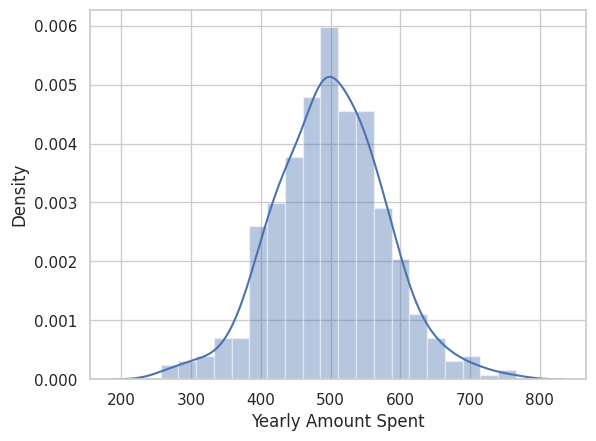

In [35]:
sns.distplot(df['Yearly Amount Spent'])

<Axes: >

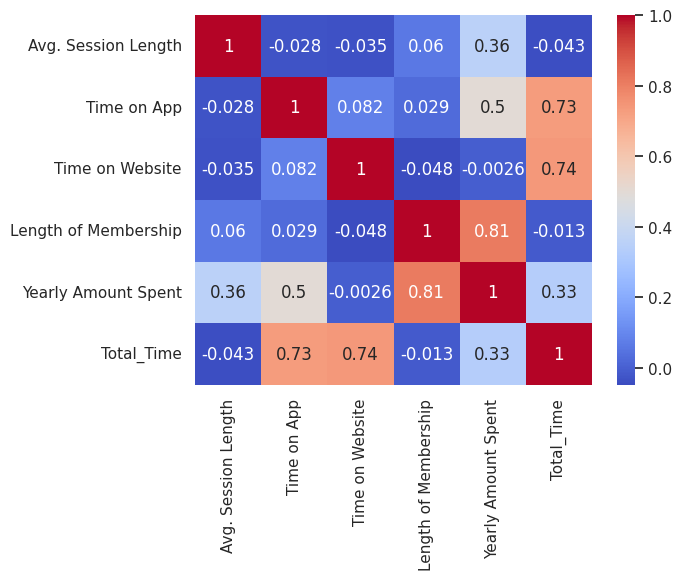

In [36]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

In [39]:
X = df[['Avg. Session Length', 'Time on App', 'Time on Website',
        'Length of Membership', 'Total_Time']]
y = df['Yearly Amount Spent']

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
lm = LinearRegression()
lm.fit(X_train, y_train)

LinearRegression()

In [42]:
print(lm.intercept_)

-1044.2574146365569


In [43]:
coeff_df = pd.DataFrame(lm.coef_,X.columns,columns=['Coefficient'])
coeff_df

,Coefficient
Avg. Session Length,25.596259
Time on App,25.753435
Time on Website,-12.721525
Length of Membership,61.896829
Total_Time,13.031911


In [44]:
predictions = lm.predict(X_test)

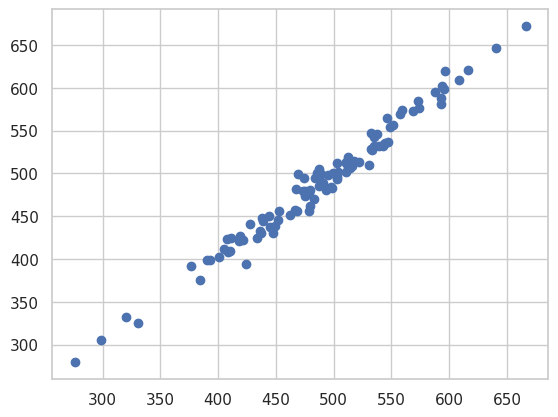

In [45]:
plt.scatter(y_test,predictions)

/tmp/ipykernel_3575/1326397652.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_test-predictions),bins=50);


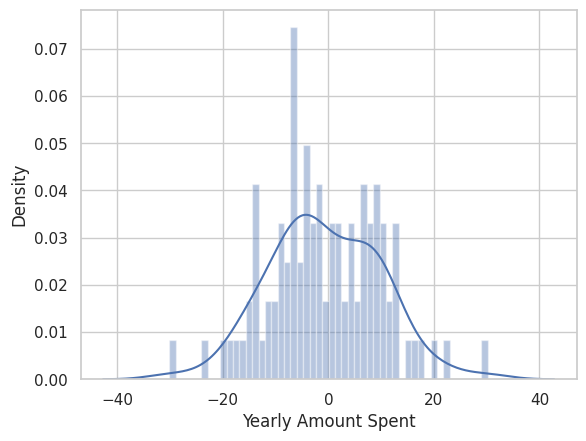

In [46]:
sns.distplot((y_test-predictions),bins=50);

In [47]:
print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE: 8.558441885315249
MSE: 109.86374118394036
RMSE: 10.481590584636493


In [51]:
print('R²:', r2_score(y_test, predictions))

R²: 0.9778130629184126
